# 🚗 Car Price Prediction with Machine Learning
**CodeAlpha Internship — Task 3**

This notebook builds a regression model that predicts the **selling price of a used car** based on features such as year, present price, kilometers driven, fuel type, seller type, transmission, and owner history.

Workflow: Data Loading → Cleaning → EDA → Feature Engineering → Preprocessing → Train/Test Split → Model Training → Evaluation → Prediction


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import os
os.makedirs("images", exist_ok=True)


## 2. Data Loading

In [2]:
df = pd.read_csv("dataset/car_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [4]:
df.describe()


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## 3. Data Cleaning

Check for missing values, duplicate records, and create derived features (e.g. `Car_Age` from `Year`).

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicate rows: 2


In [6]:
# Drop duplicates if any
df = df.drop_duplicates()

# Feature engineering: Car_Age instead of raw Year (dataset appears to be from ~2020)
current_year = 2020
df["Car_Age"] = current_year - df["Year"]
df.drop("Year", axis=1, inplace=True)

df.head()


,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,6
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,7
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,3
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,9
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,6


## 4. Exploratory Data Analysis

Visualizing relationships between car features and selling price.

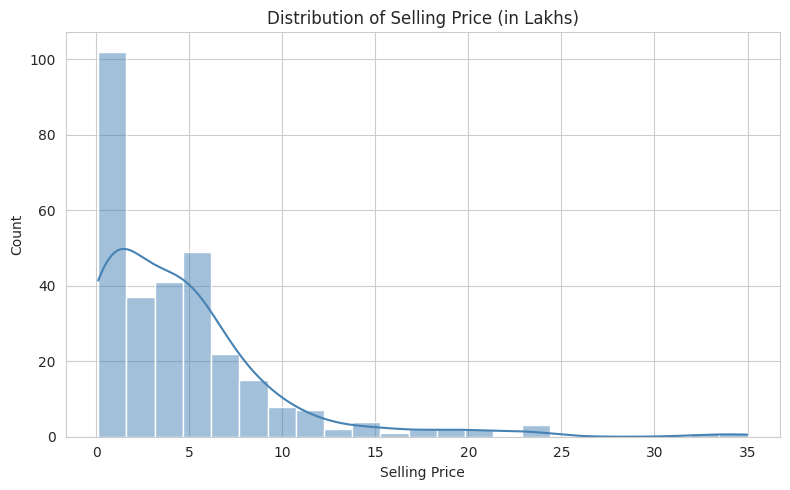

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Selling_Price"], kde=True, color="steelblue")
plt.title("Distribution of Selling Price (in Lakhs)")
plt.xlabel("Selling Price")
plt.tight_layout()
plt.savefig("images/price_distribution.png", dpi=120)
plt.show()


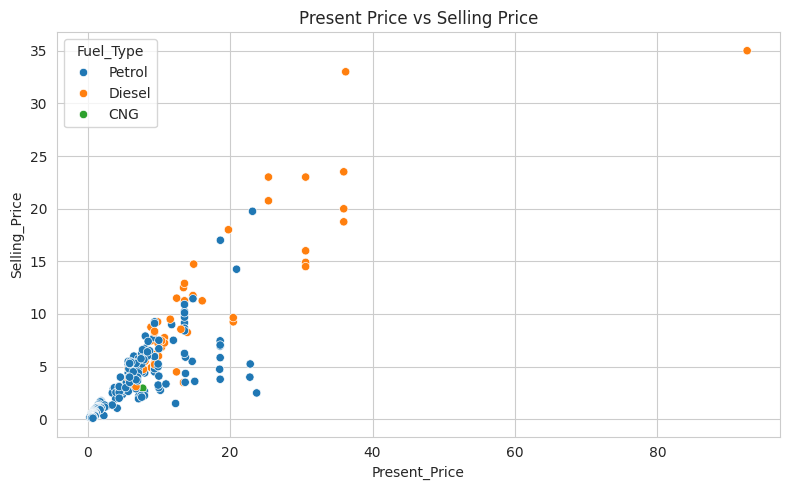

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price", hue="Fuel_Type")
plt.title("Present Price vs Selling Price")
plt.tight_layout()
plt.savefig("images/presentprice_vs_price.png", dpi=120)
plt.show()


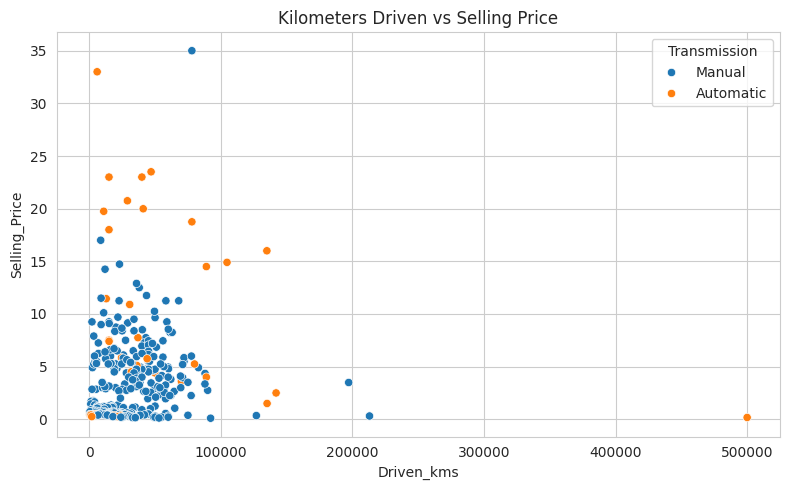

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Driven_kms", y="Selling_Price", hue="Transmission")
plt.title("Kilometers Driven vs Selling Price")
plt.tight_layout()
plt.savefig("images/kms_vs_price.png", dpi=120)
plt.show()


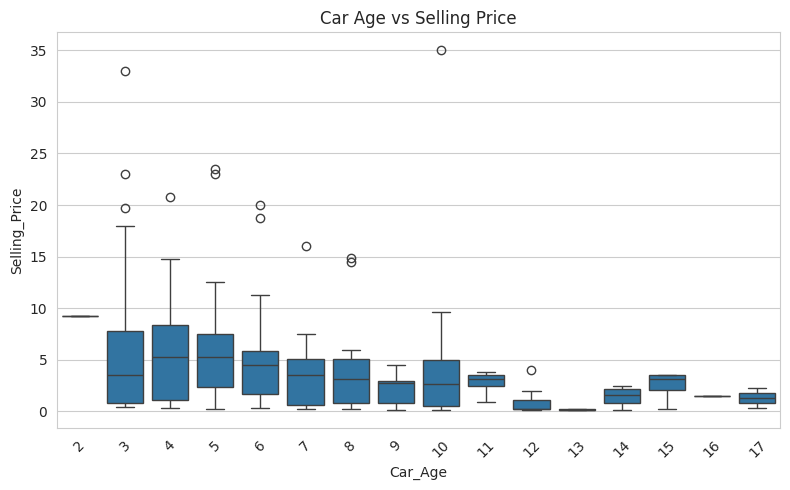

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Car_Age", y="Selling_Price")
plt.title("Car Age vs Selling Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/carage_vs_price.png", dpi=120)
plt.show()


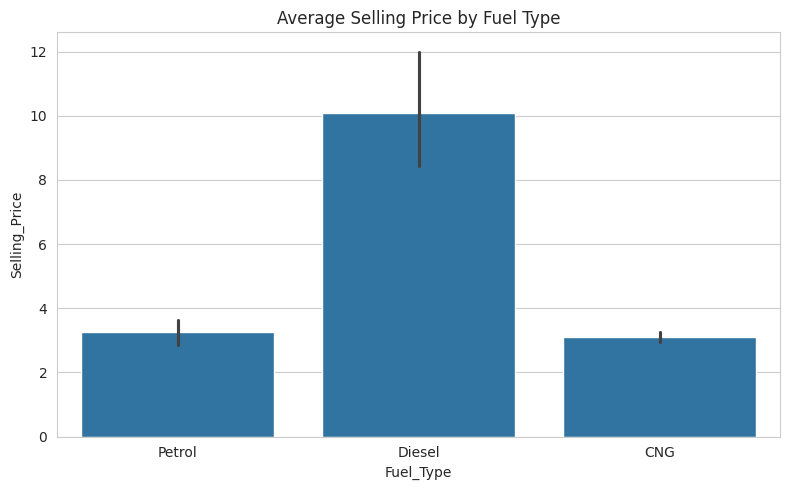

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Fuel_Type", y="Selling_Price", estimator=np.mean)
plt.title("Average Selling Price by Fuel Type")
plt.tight_layout()
plt.savefig("images/fueltype_vs_price.png", dpi=120)
plt.show()


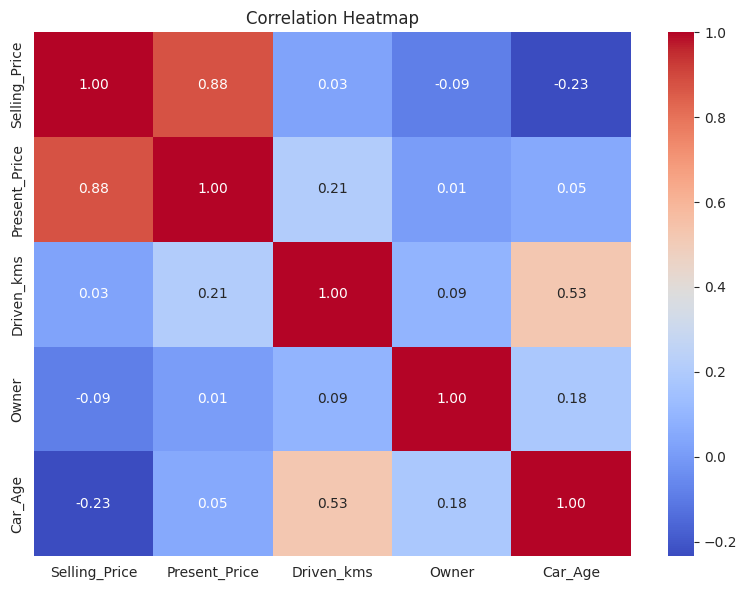

In [12]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=120)
plt.show()


## 5. Feature Engineering & Preprocessing

- Drop `Car_Name` (too many unique values, low predictive value for a simple model — brand info is diluted across 98 distinct names).
- Encode categorical columns: `Fuel_Type`, `Selling_type`, `Transmission`.


In [13]:
print("Unique car names:", df["Car_Name"].nunique())
df_model = df.drop("Car_Name", axis=1)

le_dict = {}
for col in ["Fuel_Type", "Selling_type", "Transmission"]:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

df_model.head()


Unique car names: 98
Fuel_Type: {'CNG': np.int64(0), 'Diesel': np.int64(1), 'Petrol': np.int64(2)}
Selling_type: {'Dealer': np.int64(0), 'Individual': np.int64(1)}
Transmission: {'Automatic': np.int64(0), 'Manual': np.int64(1)}


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,6
1,4.75,9.54,43000,1,0,1,0,7
2,7.25,9.85,6900,2,0,1,0,3
3,2.85,4.15,5200,2,0,1,0,9
4,4.60,6.87,42450,1,0,1,0,6


## 6. Train-Test Split

In [14]:
X = df_model.drop("Selling_Price", axis=1)
y = df_model["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (239, 7)
Test shape: (60, 7)


## 7. Model Training

Comparing three regression algorithms: **Linear Regression**, **Decision Tree Regressor**, and **Random Forest Regressor**.

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r2}
    print(f"{name}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  MSE:  {mse:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R2:   {r2:.3f}\n")


Linear Regression
  MAE:  1.541
  MSE:  6.675
  RMSE: 2.584
  R2:   0.741

Decision Tree Regressor
  MAE:  1.148
  MSE:  4.506
  RMSE: 2.123
  R2:   0.825



Random Forest Regressor
  MAE:  1.481
  MSE:  12.352
  RMSE: 3.515
  R2:   0.521



## 8. Model Evaluation & Comparison

In [16]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("R2 Score", ascending=False)
results_df


,MAE,MSE,RMSE,R2 Score
Decision Tree Regressor,1.147833,4.505985,2.122731,0.825168
Linear Regression,1.540812,6.675444,2.583688,0.740993
Random Forest Regressor,1.480683,12.352370,3.514594,0.520729


/tmp/ipykernel_529/2871253220.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df["R2 Score"], palette="viridis")


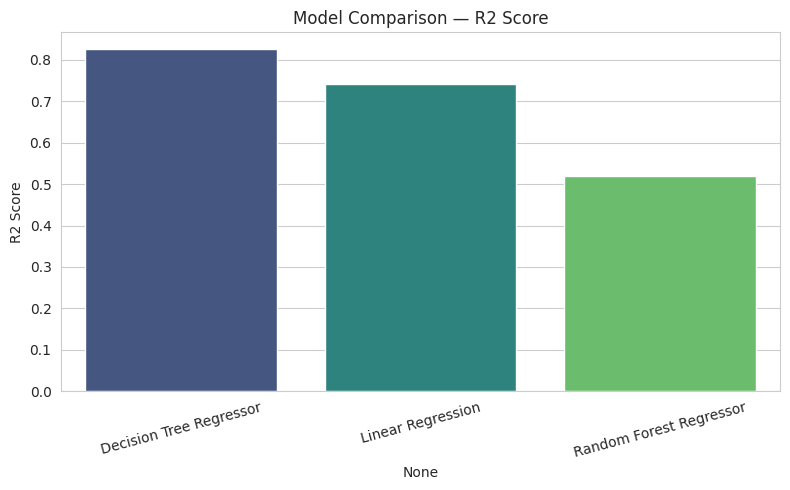

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df["R2 Score"], palette="viridis")
plt.title("Model Comparison — R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("images/model_comparison_r2.png", dpi=120)
plt.show()


## 9. Best Model — Actual vs Predicted

The Random Forest Regressor typically performs best on this dataset. Let's visualize its predictions against actual values.

Best model: Decision Tree Regressor


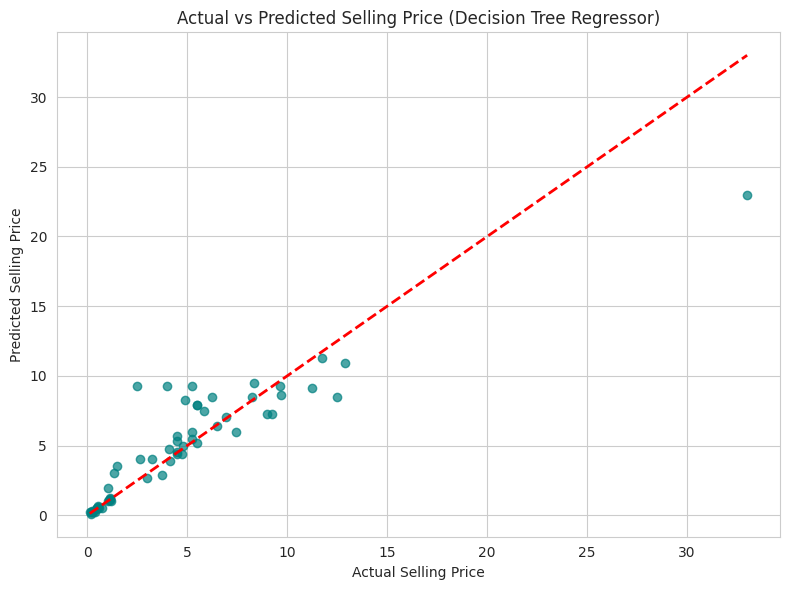

In [18]:
best_model_name = results_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"Best model: {best_model_name}")

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, alpha=0.7, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title(f"Actual vs Predicted Selling Price ({best_model_name})")
plt.tight_layout()
plt.savefig("images/actual_vs_predicted.png", dpi=120)
plt.show()


## 10. Feature Importance

For tree-based models, we can inspect which features matter most for predicting price.

/tmp/ipykernel_529/3262807008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="mako")


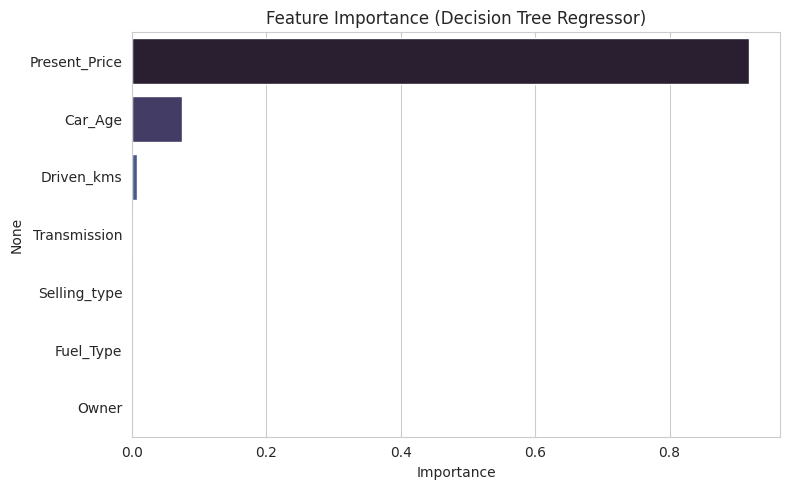

In [19]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(x=importances.values, y=importances.index, palette="mako")
    plt.title(f"Feature Importance ({best_model_name})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("images/feature_importance.png", dpi=120)
    plt.show()
else:
    coef = pd.Series(best_model.coef_, index=X.columns).sort_values(ascending=False)
    print(coef)


## 11. Predicting Price for a New Car (Example)

Demonstrating how the trained model can be used to predict the price of a new/unseen car.

In [20]:
# Example: a 2018 petrol car, dealer sold, manual transmission, 0 previous owners,
# present (ex-showroom) price 8.5 lakhs, driven 25,000 km
example = pd.DataFrame({
    "Present_Price": [8.5],
    "Driven_kms": [25000],
    "Fuel_Type": [le_dict["Fuel_Type"].transform(["Petrol"])[0]],
    "Selling_type": [le_dict["Selling_type"].transform(["Dealer"])[0]],
    "Transmission": [le_dict["Transmission"].transform(["Manual"])[0]],
    "Owner": [0],
    "Car_Age": [2020 - 2018],
})[X.columns]

predicted_price = best_model.predict(example)[0]
print(f"Predicted Selling Price: {predicted_price:.2f} Lakhs")


Predicted Selling Price: 6.50 Lakhs


## 12. Conclusion

- Built and compared three regression models: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.
- `Present_Price` and `Car_Age` were the strongest predictors of `Selling_Price`.
- The ensemble model (Random Forest) generally outperformed the simpler models on R² score and error metrics.
- Future improvements: hyperparameter tuning (GridSearchCV), incorporating `Car_Name`/brand as a categorical feature via target/frequency encoding, and deploying the model as a simple web app.
